# Plateau’s Problem (or minimal surface problem)

This notebook provides an implementation of the Plateau's problem, which finds a minimal surface shape that connects a set of interfaces.
More details on this example, can be found in [our paper](https://arxiv.org/abs/2402.14009), Sections 4.1 and A.2.

### Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from tqdm.notebook import trange
import k3d

torch.manual_seed(0)

device = 'cuda' ## TODO
torch.set_default_device(device)

### Define the boundary rectangles

In [2]:
def get_boundary_angled_rectangles(n=1000):
    ls = lambda a,b : torch.linspace(a, b, n//8, device=device)
    const = lambda c : c*torch.ones(n//8, device=device, dtype=torch.float32)
    bndry = torch.hstack([
        torch.vstack([ls(0,1), const(0), const(0)]),
        torch.vstack([ls(0,1), const(1), const(0)]),
        torch.vstack([const(0), const(0), ls(0,1)]),
        torch.vstack([const(0), ls(0,1), const(1)]),
        torch.vstack([const(0), const(1), ls(0,1)]),
        torch.vstack([const(1), const(0), ls(0,1)]),
        torch.vstack([const(1), ls(0,1), const(1)]),
        torch.vstack([const(1), const(1), ls(0,1)]),
        ]).T
    return bndry

pts_bndry = get_boundary_angled_rectangles()

bounds = torch.vstack([pts_bndry.min(0).values, pts_bndry.max(0).values]).T

fig = k3d.plot()
fig += k3d.points(pts_bndry.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()

Output()

### Define the network and derivatives

Solving this problem requires access to first and second order derivatives wrt. the input $x$ of a neural network $f_\theta(x)$ with parameters $\theta$.

In [3]:
from torch import nn
from torch import tanh, sin

class GeneralNet(nn.Module):
    def __init__(self, ks, act=tanh):
        super(GeneralNet, self).__init__()
        self.ks = ks
        self.fcs = nn.ModuleList([nn.Linear(in_features, out_features)
            for in_features, out_features in zip(self.ks[:-1],self.ks[1:])])
        self.D = len(self.fcs)
        self.act = act

    def forward(self, x):
        x = self.fcs[0](x)
        for i in range(2,self.D+1):
            x = self.fcs[i-1](self.act(x))
        return x

In [4]:
from torch.func import vmap, jacrev, jacfwd, functional_call

model = GeneralNet(ks=[3, 32, 32, 1])

params = dict(model.named_parameters())
def f(params, x):
    return functional_call(model, params, x)

## Jacobian of f with respect to the input x
f_x = jacrev(f, argnums=1)  ## params, [nx] -> [ny, nx]
vf_x = vmap(f_x, in_dims=(None, 0), out_dims=(0))  ## params, [bx, nx] -> [bx, ny, nx]
## Hessian of f with respect to the input x
f_xx = jacfwd(f_x, argnums=1)  ## params, [nx] -> [ny, nx, nx]
vf_xx = vmap(f_xx, in_dims=(None, 0), out_dims=(0))  ## params, [bx, nx] -> [bx, ny, nx, nx]
# Laplacian of f with respect to the input x
def laplacian_f(params, x):
    hessian = f_xx(params, x).squeeze(1)  # Compute the Hessian
    laplacian = torch.einsum('bii->b', hessian)  # Sum of the diagonal elements to get the Laplacian
    return laplacian
v_laplacian_f = vmap(laplacian_f, in_dims=(None, 0), out_dims=(0))
## Phi (Gradients of f wrt theta)
f_theta = jacrev(f, argnums=0)  # dict
vf_theta = vmap(f_theta, in_dims=(None, 0), out_dims=(0))
## Grad Phi (Gradients of Phi wrt x)
phi_x = jacfwd(f_theta, argnums=1)  # dict
v_phi_x = vmap(phi_x, in_dims=(None, 0), out_dims=(0))
## Laplacian of Phi
laplacian_phi = jacrev(laplacian_f, argnums=0) # dict
v_laplacian_phi = vmap(laplacian_phi, in_dims=(None, 0), out_dims=(0))

### Calculate Hessian approximations

In [ ]:
# Approximate Hessians

def calculate_A_interface(vf_theta, params, pts_bndry):
    """
    Calculate the boundary integral matrix A_bndry.
    
    Args:
        vf_theta: Function mapping parameters and points to derivatives (jacobian).
        params: Model parameters as a dictionary.
        pts_bndry: Boundary points as a tensor of shape [n_points, n_dims].
        interface_length: Length of the interface for scaling (default: 8).
        
    Returns:
        torch.Tensor: Approximate Hessian of the boundary loss [n_params, n_params].
    """
    # Compute φ_i at boundary points
    phi_at_pts = vf_theta(params, pts_bndry)  # Returns a dict

    # Aggregate φ_i into a single tensor
    phi_at_pts_tensor = torch.cat([p.flatten(start_dim=1) for p in phi_at_pts.values()], dim=1)  # Shape: [n_points, n_params]
    A_bndry = torch.einsum('bi,bj->ij', phi_at_pts_tensor, phi_at_pts_tensor) / len(pts_bndry)

    return A_bndry


def calculate_A_eikonal(v_phi_x, vf_x, params, pts):
    """
    Calculate the eikonal integral matrix A_eikonal.
    
    Args:
        v_phi_x: Function mapping parameters and points to gradients of phi (jacobian).
        vf_x: Function mapping parameters and points to gradients of f (jacobian).
        params: Model parameters as a dictionary.
        pts: Points in the space as a tensor of shape [n_points, n_dims].
        
    Returns:
        torch.Tensor: Approximate Hessian of the eikonal loss [n_params, n_params].
    """
    grad_phi_at_pts = v_phi_x(params, pts)  # Returns a dict
    grad_f_at_pts = vf_x(params, pts)  # Returns a tensor of shape [n_points, 1, n_dims]
    grad_f_at_pts = grad_f_at_pts / torch.norm(grad_f_at_pts, dim=-1, keepdim=True)**(1.5)

    # Aggregate gradients into a single tensor
    grad_phi_tensor = torch.cat([p.flatten(start_dim=1) for p in grad_phi_at_pts.values()], dim=1)  # Shape: [n_points, n_params * n_dims]
    # Reshape to separate the dimensions
    n_points, n_params_times_dims = grad_phi_tensor.shape
    n_dims = pts.shape[1]
    n_params = n_params_times_dims // n_dims
    grad_phi_tensor = grad_phi_tensor.reshape(n_points, n_params, n_dims)  # Shape: [n_points, n_params, n_dims]
    A_eikonal = torch.einsum('bik,bjk->ij', grad_phi_tensor, grad_phi_tensor)/n_points

    cross_product_term = torch.cross(grad_phi_tensor, grad_f_at_pts, dim=-1)
    cross_product_term = torch.einsum('bik,bjk->ij', cross_product_term, cross_product_term)/n_points
    A_eikonal -= cross_product_term
    return A_eikonal

def calculate_A_laplacian(v_laplacian_phi, params, pts):
    """
    Calculate the Laplacian integral matrix A_laplacian.
    
    Args:
        vf_theta_lap: Function mapping parameters and points to Laplacians (second derivatives).
        params: Model parameters as a dictionary.
        pts: Surface points as a tensor of shape [n_points, n_dims].
        
    Returns:
        torch.Tensor: Approximate Hessian of the laplacian loss [n_params, n_params].
    """
    
    # Compute Laplacians of φ_i at points
    lap_phi_at_pts = v_laplacian_phi(params, pts)  # Returns a dict
    
    # Aggregate Laplacians into a single tensor
    lap_phi_tensor = torch.cat([p.flatten(start_dim=1) for p in lap_phi_at_pts.values()], dim=1)  # Shape: [n_points, n_params]
    A_laplacian = torch.einsum('bi,bj->ij', lap_phi_tensor, lap_phi_tensor) / len(pts_bndry)

    return A_laplacian

def get_param_shapes(model):
    """
    Extracts parameter shapes from a PyTorch model.
    
    Args:
        model (torch.nn.Module): The PyTorch model.
    
    Returns:
        dict: A dictionary where keys are parameter names and values are their shapes.
    """
    param_shapes = {}
    for name, param in model.named_parameters():
        param_shapes[name] = param.shape
    return param_shapes

def reshape_block(block, param_shape_row, param_shape_col):
    """
    Reshapes a Hessian block into a 2D matrix based on parameter shapes.
    
    Args:
        block (torch.Tensor): Input block with varying dimensions.
        param_shape_row (torch.Size): Shape of the row parameter.
        param_shape_col (torch.Size): Shape of the column parameter.
    
    Returns:
        torch.Tensor: Reshaped or padded block.
    """
    # Flatten parameter shapes
    param_size_row = torch.prod(torch.tensor(param_shape_row)).item()
    param_size_col = torch.prod(torch.tensor(param_shape_col)).item()

    # Reshape block
    if len(block.shape) == 4:
        block = block.reshape(param_size_row, param_size_col)
    elif len(block.shape) == 3:
        block = block.reshape(param_size_row, param_size_col)
    elif len(block.shape) == 2:
        block = block
    else:
        raise ValueError(f"Unexpected block shape: {block.shape}")

    # Ensure the block matches expected dimensions
    if block.shape[0] != param_size_row or block.shape[1] != param_size_col:
        raise ValueError(f"Block shape mismatch: {block.shape} vs ({param_size_row}, {param_size_col})")
    
    return block

def build_hessian_matrix(hessian_dict, param_shapes):
    """
    Constructs the full Hessian matrix as a torch tensor from the Hessian dictionary.
    
    Args:
        hessian_dict (dict): Nested dictionary of Hessian blocks.
        param_shapes (dict): Dictionary of parameter names and their shapes.
    
    Returns:
        torch.Tensor: The full Hessian matrix.
    """
    # Compute total size of all parameters
    total_size = sum(torch.prod(torch.tensor(shape)).item() for shape in param_shapes.values())
    hessian_matrix = torch.zeros((total_size, total_size))  # Initialize square matrix
    
    row_offset = 0
    for key1, inner_dict in hessian_dict.items():
        col_offset = 0
        for key2, block in inner_dict.items():
            # Get parameter shapes for the current block
            param_shape_row = param_shapes[key1]
            param_shape_col = param_shapes[key2]
            
            # Reshape the block
            reshaped_block = reshape_block(block, param_shape_row, param_shape_col)
            
            # Place the reshaped block in the Hessian matrix
            param_size_row = torch.prod(torch.tensor(param_shape_row)).item()
            param_size_col = torch.prod(torch.tensor(param_shape_col)).item()
            hessian_matrix[row_offset:row_offset + param_size_row,
                           col_offset:col_offset + param_size_col] = reshaped_block
            col_offset += param_size_col
        row_offset += param_size_row
    
    return hessian_matrix

In [6]:
# grad_phi_at_pts = v_phi_x(params, pts)  # Returns a dict
# grad_f_at_pts = vf_x(params, pts)  # Returns a tensor of shape [n_points, 1, n_dims]


# # Aggregate gradients into a single tensor
# grad_phi_tensor = torch.cat([p.flatten(start_dim=1) for p in grad_phi_at_pts.values()], dim=1)  # Shape: [n_points, n_params * n_dims]
# # Reshape to separate the dimensions
# n_points, n_params_times_dims = grad_phi_tensor.shape
# n_dims = pts.shape[1]
# n_params = n_params_times_dims // n_dims
# grad_phi_tensor = grad_phi_tensor.reshape(n_points, n_params, n_dims)  # Shape: [n_points, n_params, n_dims]
# A_eikonal = torch.einsum('bik,bjk->ij', grad_phi_tensor, grad_phi_tensor)/n_points

### Main training loop

In [7]:
def boundary_loss(params, pts_bndry):
    return f(params, pts_bndry).square().mean()

def eikonal_loss(params, pts):
    return (vf_x(params, pts).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

def laplacian_loss(params, pts):
    return v_laplacian_f(params, pts).square().mean()

param_shapes = get_param_shapes(model)

optim = torch.optim.Adam(model.parameters(), lr=1e-3)
pts_corners = torch.tensor([
    [0,0,0],
    [1,0,0],
    [1,0,1],
    [1,1,1],
    [1,1,0],
    [0,1,0],
    [0,1,1],
    [0,0,1],
    [0,0,0],
    ], dtype=torch.float32)

loss_over_iters = {}

log_data = {
    'relative_norm_interface': [],
    'max_abs_eigenvalue_A_interface': [],
    'max_abs_eigenvalue_hessian_interface': [],
    'relative_norm_eikonal': [],
    'max_abs_eigenvalue_A_eikonal': [],
    'max_abs_eigenvalue_hessian_eikonal': [],
    'relative_norm_laplacian': [],
    'max_abs_eigenvalue_A_laplacian': [],
    'max_abs_eigenvalue_hessian_laplacian': [],
    'epochs': []
}
for i in (pbar:=trange(10000)):
    optim.zero_grad()

    ## 1) Interface at boundaries
    loss_interface  = f(params, pts_bndry).square().mean()
    loss_interface += 10*f(params, pts_corners).square().mean()
    
    ## 2) Eikonal at boundaries (or everywhere?)
    loss_eikonal  = (vf_x(params, pts_bndry).squeeze(1).square().sum(1).sqrt() - 1).square().mean()
    loss_eikonal += 10*(vf_x(params, pts_corners).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

    ## 3) Mean curvature on the 0-surface
    if i<1000:
        # loss_curvature = torch.zeros([1,1])
        loss_laplacian = torch.zeros([1,1])
        pts = []
    else:
        ## Sample points on surface
        pts = torch.rand([10000, 3])
        vals_sq = model(pts).square().squeeze()
        pts = pts[vals_sq<1e-4]
        if len(pts):
            # Fs = vf_x(params, pts).squeeze(1)
            # Hs = vf_xx(params, pts).squeeze(1)
            # mean_curvatures = get_mean_curvature(Fs, Hs)
            # loss_curvature = mean_curvatures.square().mean()
            laplacian = v_laplacian_f(params, pts).squeeze(1)
            loss_laplacian = laplacian.square().mean()
    
    if i % 500 == 0:
        # Calculate the approximate Hessian A_bndry
        A_interface = 2 * calculate_A_interface(vf_theta, params, pts_bndry)  # 2 comes from derivative because we don't take 1/2 in the loss
        
        gradient_boundary_loss = jacrev(boundary_loss, argnums=0)
        hessian_boundary_loss = jacfwd(gradient_boundary_loss, argnums=0)
        hessian_boundary_loss_tensor = build_hessian_matrix(hessian_boundary_loss(params, pts_bndry), param_shapes)
        
        norm_diff_interface = torch.norm(hessian_boundary_loss_tensor - A_interface, p=2)
        norm_interface = torch.norm(hessian_boundary_loss_tensor, p=2)
        relative_norm_interface = norm_diff_interface.item() / norm_interface.item()
        print(f"Step {i}: relative norm of the difference (interface): {relative_norm_interface}")
        
        # Compute the maximum absolute eigenvalue of A_interface and the Hessian
        eigenvalues_A_interface = torch.linalg.eigvals(A_interface)
        max_abs_eigenvalue_A_interface = torch.max(torch.abs(eigenvalues_A_interface)).item()
        print(f"Step {i}: maximum absolute eigenvalue of A_interface: {max_abs_eigenvalue_A_interface}")
        
        eigenvalues_hessian_interface = torch.linalg.eigvals(hessian_boundary_loss_tensor)
        max_abs_eigenvalue_hessian_interface = torch.max(torch.abs(eigenvalues_hessian_interface)).item()
        print(f"Step {i}: maximum absolute eigenvalue of Hessian (interface): {max_abs_eigenvalue_hessian_interface}")

        torch.cuda.empty_cache()
        
        # Log the values
        log_data['relative_norm_interface'].append(relative_norm_interface)
        log_data['max_abs_eigenvalue_A_interface'].append(max_abs_eigenvalue_A_interface)
        log_data['max_abs_eigenvalue_hessian_interface'].append(max_abs_eigenvalue_hessian_interface)
        log_data['epochs'].append(i)
        
        # # Calculate the approximate Hessian A_eikonal
        # pts_eik = torch.rand([100, 3])
        # A_eikonal = 2 * calculate_A_eikonal(v_phi_x, vf_x, params, pts_eik)  # 2 comes from derivative because we don't take 1/2 in the loss
        
        # gradient_eikonal_loss = jacrev(eikonal_loss, argnums=0)
        # hessian_eikonal_loss = jacfwd(gradient_eikonal_loss, argnums=0)
        # hessian_eikonal_loss_tensor = build_hessian_matrix(hessian_eikonal_loss(params, pts_eik), param_shapes)
        
        # norm_diff_eikonal = torch.norm(hessian_eikonal_loss_tensor - A_eikonal, p=2)
        # norm_eikonal = torch.norm(hessian_eikonal_loss_tensor, p=2)
        # relative_norm_eikonal = norm_diff_eikonal.item() / norm_eikonal.item()
        # print(f"Step {i}: relative norm of the difference (eikonal): {relative_norm_eikonal}")
        
        # # Compute the maximum absolute eigenvalue of A_eikonal and the Hessian
        # eigenvalues_A_eikonal = torch.linalg.eigvals(A_eikonal)
        # max_abs_eigenvalue_A_eikonal = torch.max(torch.abs(eigenvalues_A_eikonal)).item()
        # print(f"Step {i}: maximum absolute eigenvalue of A_eikonal: {max_abs_eigenvalue_A_eikonal}")
        
        # eigenvalues_hessian_eikonal = torch.linalg.eigvals(hessian_eikonal_loss_tensor)
        # max_abs_eigenvalue_hessian_eikonal = torch.max(torch.abs(eigenvalues_hessian_eikonal)).item()
        # print(f"Step {i}: maximum absolute eigenvalue of Hessian (eikonal): {max_abs_eigenvalue_hessian_eikonal}")

        # torch.cuda.empty_cache()
        
        # # Log the values
        # log_data['relative_norm_eikonal'].append(relative_norm_eikonal)
        # log_data['max_abs_eigenvalue_A_eikonal'].append(max_abs_eigenvalue_A_eikonal)
        # log_data['max_abs_eigenvalue_hessian_eikonal'].append(max_abs_eigenvalue_hessian_eikonal)
        
        if i > 1000:
            A_laplacian = 2 * calculate_A_laplacian(vf_theta, params, pts)  # 2 comes from derivative because we don't take 1/2 in the loss
            
            gradient_laplacian_loss = jacrev(boundary_loss, argnums=0)
            hessian_laplacian_loss = jacfwd(gradient_laplacian_loss, argnums=0)
            hessian_laplacian_loss_tensor = build_hessian_matrix(hessian_laplacian_loss(params, pts), param_shapes)
            
            norm_diff_laplacian = torch.norm(hessian_laplacian_loss_tensor - A_laplacian, p=2)
            norm_laplacian = torch.norm(hessian_laplacian_loss_tensor, p=2)
            relative_norm_laplacian = norm_diff_laplacian.item() / norm_laplacian.item()
            print(f"Step {i}: relative norm of the difference (laplacian): {relative_norm_laplacian}")
            
            # Compute the maximum absolute eigenvalue of A_laplacian and the Hessian
            eigenvalues_A_laplacian = torch.linalg.eigvals(A_laplacian)
            max_abs_eigenvalue_A_laplacian = torch.max(torch.abs(eigenvalues_A_laplacian)).item()
            print(f"Step {i}: maximum absolute eigenvalue of A_laplacian: {max_abs_eigenvalue_A_laplacian}")
            
            eigenvalues_hessian_laplacian = torch.linalg.eigvals(hessian_laplacian_loss_tensor)
            max_abs_eigenvalue_hessian_laplacian = torch.max(torch.abs(eigenvalues_hessian_laplacian)).item()
            print(f"Step {i}: maximum absolute eigenvalue of Hessian (laplacian): {max_abs_eigenvalue_hessian_laplacian}")

            torch.cuda.empty_cache()
            
            # Log the values
            log_data['relative_norm_laplacian'].append(relative_norm_laplacian)
            log_data['max_abs_eigenvalue_A_laplacian'].append(max_abs_eigenvalue_A_laplacian)
            log_data['max_abs_eigenvalue_hessian_laplacian'].append(max_abs_eigenvalue_hessian_laplacian)


    # loss = loss_interface + loss_eikonal + loss_curvature
    loss = loss_interface + loss_eikonal + loss_laplacian
    loss.backward(retain_graph=True)
    optim.step()

    pbar.set_description(f"interface: {loss_interface.item():.2e} "
                         f"eikonal: {loss_eikonal.item():.2e} "
                         # f"curvature: {loss_curvature.item():.2e} "
                         f"laplacian: {loss_laplacian.item():.2e} "
                         f"{len(pts)}"
                        )
    loss_over_iters[i] = loss.item()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

Step 0: relative norm of the difference (interface): 0.6641085930509892
Step 0: maximum absolute eigenvalue of A_interface: 7.558607578277588
Step 0: maximum absolute eigenvalue of Hessian (interface): 7.785815715789795
Step 500: relative norm of the difference (interface): 0.08443238578725949
Step 500: maximum absolute eigenvalue of A_interface: 19.05964469909668
Step 500: maximum absolute eigenvalue of Hessian (interface): 19.034652709960938
Step 1000: relative norm of the difference (interface): 0.10462548698413171
Step 1000: maximum absolute eigenvalue of A_interface: 19.44216537475586
Step 1000: maximum absolute eigenvalue of Hessian (interface): 19.44264793395996
Step 1500: relative norm of the difference (interface): 0.09860793415640431
Step 1500: maximum absolute eigenvalue of A_interface: 21.37790870666504
Step 1500: maximum absolute eigenvalue of Hessian (interface): 21.37891387939453
Step 1500: relative norm of the difference (laplacian): 0.7909957707445292
Step 1500: maximu

KeyboardInterrupt: 

### Visualize the result

In [7]:
import sys
sys.path.append('..')
from util.visualization.utils_mesh import get_mesh

verts, faces = get_mesh(model, N=128, device=device, bbox_min=bounds[:,0]-.01, bbox_max=bounds[:,1]+.01, chunks=2)

In [8]:
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.line(pts_corners.cpu(), color=0x00ff00, shader='mesh', radial_segments=4, opacity=.5)
fig.display()

c:\Users\james\Desktop\Studium ETH\Master Thesis\GINN Code\ginn_env\lib\site-packages\traittypes\traittypes.py:97: UserWarning: Given trait value dtype "int32" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

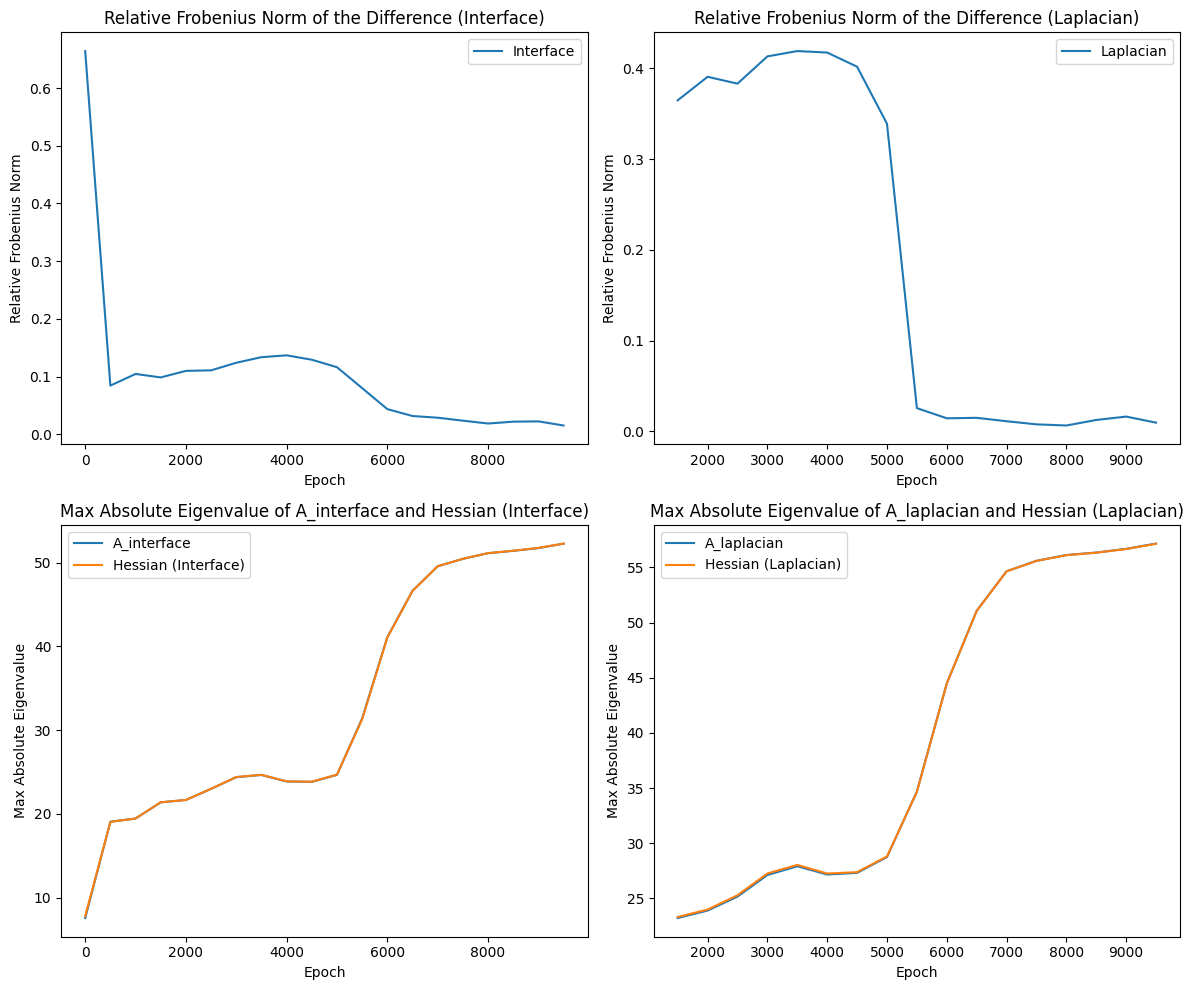

In [11]:
# Plot the logged values
plt.figure(figsize=(12, 10))

# Plot relative Frobenius norm of the difference (interface)
plt.subplot(2, 2, 1)
plt.plot(log_data['epochs'], log_data['relative_frobenius_norm_interface'], label='Interface')
plt.xlabel('Epoch')
plt.ylabel('Relative Frobenius Norm')
plt.title('Relative Frobenius Norm of the Difference (Interface)')
plt.legend()

# Plot relative Frobenius norm of the difference (laplacian)
plt.subplot(2, 2, 2)
plt.plot(log_data['epochs'][3:], log_data['relative_frobenius_norm_laplacian'], label='Laplacian')
plt.xlabel('Epoch')
plt.ylabel('Relative Frobenius Norm')
plt.title('Relative Frobenius Norm of the Difference (Laplacian)')
plt.legend()

# Plot maximum absolute eigenvalue of A_interface and Hessian (interface)
plt.subplot(2, 2, 3)
plt.plot(log_data['epochs'], log_data['max_abs_eigenvalue_A_interface'], label='A_interface')
plt.plot(log_data['epochs'], log_data['max_abs_eigenvalue_hessian_interface'], label='Hessian (Interface)')
plt.xlabel('Epoch')
plt.ylabel('Max Absolute Eigenvalue')
plt.title('Max Absolute Eigenvalue of A_interface and Hessian (Interface)')
plt.legend()

# Plot maximum absolute eigenvalue of A_laplacian and Hessian (laplacian)
plt.subplot(2, 2, 4)
plt.plot(log_data['epochs'][3:], log_data['max_abs_eigenvalue_A_laplacian'], label='A_laplacian')
plt.plot(log_data['epochs'][3:], log_data['max_abs_eigenvalue_hessian_laplacian'], label='Hessian (Laplacian)')
plt.xlabel('Epoch')
plt.ylabel('Max Absolute Eigenvalue')
plt.title('Max Absolute Eigenvalue of A_laplacian and Hessian (Laplacian)')
plt.legend()

plt.tight_layout()
plt.show()